# 🎙️ Denoising Autoencoder: Cancelación de Ruido de Voz

## 1. Caso de Uso

Implementación de un modelo basado en Autoencoders para limpiar y eliminar el ruido de fondo de grabaciones de voz, simulando el motor de audio de aplicaciones de comunicación como Discord o Zoom.

**Dataset:** Para entrenar la red, utilizaremos el **Speech Noise Dataset** que proporciona audios ya estructurados en carpetas de voz limpia (`clean_speech`), ruido ambiente (`noise_only`) y la mezcla de ambos (`noisy_speech`). Esto nos proporciona los pares exactos de "señal ruidosa vs señal limpia" necesarios para que el Autoencoder aprenda a reconstruir la voz humana ignorando las frecuencias caóticas.

In [8]:
import os
import shutil
import kagglehub

# Ruta local
local_data_dir = os.path.join(os.getcwd(), "..", "data")
dataset_name = "abdullahhaydarkadolu/speech-noise-dataset"

# Descargar con kagglehub
download_path = kagglehub.dataset_download(dataset_name)

# Mover los archivos a la ruta local
if not os.path.exists(local_data_dir):
    os.makedirs(local_data_dir)

# Movemos el dataset a la ruta local
if len(os.listdir(local_data_dir)) == 0:
    for item in os.listdir(download_path):
        s = os.path.join(download_path, item)
        d = os.path.join(local_data_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d)
        else:
            shutil.copy2(s, d)
    print(f"¡Hecho! Dataset listo en tu carpeta local: {local_data_dir}")
else:
    print("Los datos ya están presentes en la carpeta local 'data'. Saltando paso.")   

¡Hecho! Dataset listo en tu carpeta local: c:\Users\Alumno_AI\Desktop\voice-denoising-autoencoder\notebooks\..\data


## 2. Transformación de Audio a Imágenes (Espectrogramas)

Las redes neuronales convolucionales están diseñadas para procesar datos en dos dimensiones, no ondas de audio unidimensionales. Por lo que debemos transformar nuestros archivos `.wav` en **espectrogramas**.

Un espectrograma es una representación visual del sonido:
- **Eje X:** Tiempo.
- **Eje Y:** Frecuencia (Hz).
- **Color:** Intensidad o volumen (Decibelios).

### 1. Función para pasar de audio a espectrograma

Para cumplir con el preprocesado de datos exigido, usaremos la librería `librosa` para calcular la Transformada Rápida de Fourier (STFT), normalizar los valores entre 0 y 1, y guardar las matrices en formato `.npy` (Numpy), lo cual acelerará drásticamente el entrenamiento de nuestro Autoencoder.

In [9]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Rutas origen
clean_dir = os.path.join(local_data_dir, "speech-noise-dataset/clean_speech")
noisy_dir = os.path.join(local_data_dir, "speech-noise-dataset/noisy_speech")

# Rutas destino (espectrogramas)
output_clean_dir = os.path.join(local_data_dir, "processed_clean")
output_noisy_dir = os.path.join(local_data_dir, "processed_noisy")
os.makedirs(output_clean_dir, exist_ok=True)
os.makedirs(output_noisy_dir, exist_ok=True)

def audio_to_spectrogram(audio_path, output_path, n_fft=1024, hop_length=256):
    try:
        # Cargamos el audio a 16kHz
        y, sr = librosa.load(audio_path, sr=16000)

        # Homogeneizamos la longitud (2s) para que todos los espectrogramas tengan el mismo tamaño al entrar a la red
        target_length = 32000
        if len(y) > target_length:
            y = y[:target_length]
        else:
            y = np.pad(y, (0, max(0, target_length - len(y))), "constant")

        # Calculamos STFT y pasamos a decibelios
        stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
        spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

        # Normalizamos
        spectrogram = (spectrogram - spectrogram.min()) / (spectrogram.max() - spectrogram.min() + 1e-8)

        # Guardamos el espectrograma
        np.save(output_path, spectrogram)
        return True
    except Exception as e:
        print(f"Error en {audio_path}: {e}")
        return False

### 2. Procesamiento Masivo del Dataset

A continuación, iteramos sobre nuestra carpeta de datos. Es crucial asegurarnos de emparejar correctamente cada archivo de voz ruidosa con su equivalente en voz limpia. Solo procesaremos un archivo si tenemos ambas versiones, garantizando así la correspondencia exacta *(X -> Y)* que el Autoencoder necesita para aprender a limpiar el ruido.

In [10]:
# Archivos disponibles
archivos_limpios = [f for f in os.listdir(clean_dir) if f.endswith(".wav")]
procesados = 0

print(f"Iniciando transformación de archivos...")

for archivo in archivos_limpios:
    path_clean = os.path.join(clean_dir, archivo)
    path_noisy = os.path.join(noisy_dir, archivo)

    out_clean = os.path.join(output_clean_dir, archivo.replace(".wav", ".npy"))
    out_noisy = os.path.join(output_noisy_dir, archivo.replace(".wav", ".npy"))

    # Comprobamos que el par ruidoso existe
    if os.path.exists(path_noisy):
        # Transformamos ambos
        ok_c = audio_to_spectrogram(path_clean, out_clean)
        ok_n = audio_to_spectrogram(path_noisy, out_noisy)

        if ok_c and ok_n:
            procesados += 1

    if procesados % 200 == 0 and procesados > 0:
        print(f"-> {procesados} pares de espectrogramas procesados...")

print("✅ Preprocesado completado con éxito.")

Iniciando transformación de archivos...
-> 200 pares de espectrogramas procesados...
-> 400 pares de espectrogramas procesados...
-> 600 pares de espectrogramas procesados...
-> 800 pares de espectrogramas procesados...
-> 1000 pares de espectrogramas procesados...
-> 1200 pares de espectrogramas procesados...
✅ Preprocesado completado con éxito.


### 3. Verificación Visual

Antes de construir la arquitectura del Autoencoder, vamos a graficar uno de los pares procesados. Lo que nos permitirá entender cómo ve los datos nuestro modelo.

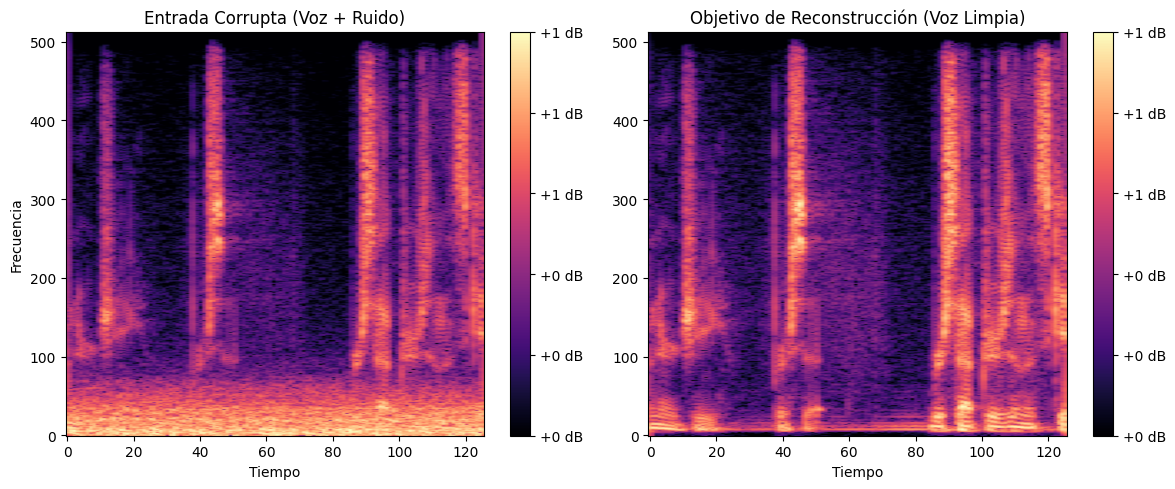

Forma del espectrograma (Input Shape): (513, 126)


In [12]:
import random

# Archivo aleatorio de los procesados
archivos_npy = os.listdir(output_clean_dir)
ejemplo = random.choice(archivos_npy)

# Cargamos las matrices
spec_clean = np.load(os.path.join(output_clean_dir, ejemplo))
spec_noisy = np.load(os.path.join(output_noisy_dir, ejemplo))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Entrada Corrupta (Voz + Ruido)")
plt.imshow(spec_noisy, aspect='auto', origin='lower', cmap='magma') 
plt.ylabel("Frecuencia")
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')
plt.subplot(1, 2, 2)
plt.title("Objetivo de Reconstrucción (Voz Limpia)")
plt.imshow(spec_clean, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

print(f"Forma del espectrograma (Input Shape): {spec_clean.shape}")

### Conclusiones

Al observar la gráfica generada, podemos confirmar el éxito del preprocesamiento:
1. **Entrada Corrupta (Izquierda):** Se aprecia cómo las frecuencias bajas (la parte inferior del gráfico, entre 0 y 100 Hz) están "sucias" con una franja anaranjada continua. Esto representa el ruido de fondo constante que interfiere con la señal principal.
2. **Objetivo de Reconstrucción (Derecha):** En la señal limpia, esa franja inferior de ruido desaparece, dejando un fondo negro (silencio) y destacando únicamente los picos de energía que corresponden a la voz humana.

El trabajo de nuestro Autoencoder será precisamente aprender a transformar la imagen de la izquierda en la de la derecha.

**Definición de Dimensiones:**
El código nos ha devuelto que la forma del espectrograma es `(513, 126)`. 
* `513` corresponde a las bandas de frecuencia (Eje Y).
* `126` corresponde a los fragmentos de tiempo (Eje X).
* Como estamos procesando imágenes en blanco y negro (aunque apliquemos un mapa de color para verlo mejor), añadiremos un canal al final.

Por lo tanto, la dimensión de entrada para nuestra primera capa en Keras será: `(513, 126, 1)`.

## 3. Arquitectura del Denoising Autoencoder

A continuación, implementamos la red neuronal, que constará de tres partes fundamentales:

1. **Encoder:** Utiliza capas convolucionales (`Conv2D`) y de agrupamiento (`MaxPooling2D`) para reducir la dimensionalidad espacial del espectrograma, extrayendo las características esenciales como las frecuencias vocales, y descartando el ruido.
2. **Bottleneck:** Es el punto de máxima compresión. Controlar la capacidad aquí es muy importante, ya que si es muy grande la red memorizará el ruido. Pero si es muy pequeño, perderemos calidad de voz quedando un efecto robótico.
3. **Decoder:** Utiliza convoluciones y submuestreo (`UpSampling2D`) para expandir el espacio latente y reconstruir el espectrograma limpio.

Debido a que nuestra entrada original tiene dimensiones `(513, 126, 1)`, que no son divisibles entre 2, es necesario incluir capas de redimensionamiento (`Resizing`) al principio para redimensionar a `(512, 128, 1)` y al final de nuevo a `(513, 126, 1)`. Así descartamos posibles desajustes de tamaño durante el proceso. 

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Input shape del preprocesamiento
input_shape = (513, 126, 1)
inputs = keras.Input(shape=input_shape, name="espectrograma_corrupto")

# Resizing para evitar desajustes
x = layers.Resizing(512, 128, name="ajuste_entrada")(inputs)

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="bottleneck")(x)

# Decoder
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

# Output con sigmoid (valores normalizados)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Resizing al tamaño original
decoded = layers.Resizing(513, 126, name="ajuste_salida")(x)

# Compilamos el modelo con MSE para medir el error de reconstrucción
autoencoder = keras.Model(inputs, decoded, name="Denoising_Autoencoder_Audio")
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

autoencoder.summary()

Model: "Denoising_Autoencoder_Audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ espectrograma_corrupto          │ (None, 513, 126, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ajuste_entrada (Resizing)       │ (None, 512, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 64, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 32, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 64, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 128, 32, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 32, 64)    │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 256, 64, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 64, 32)    │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 512, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 512, 128, 1)    │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ajuste_salida (Resizing)        │ (None, 513, 126, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento del Modelo

### 1. Carga de Datos y División (Train / Val / Test)

Cabe recordar que nuestros datos a usar son los procesados en lugar de los originales del dataset:
* **X (Entrada):** Los espectrogramas con ruido (`processed_noisy`).
* **Y (Objetivo):** Los espectrogramas limpios (`processed_clean`).

In [14]:
from sklearn.model_selection import train_test_split

# Archivos disponibles
archivos = sorted(os.listdir(output_clean_dir))

X_lista = []
Y_lista = []

for archivo in archivos:
    path_n = os.path.join(output_noisy_dir, archivo)
    path_c = os.path.join(output_clean_dir, archivo)
    
    if os.path.exists(path_n) and os.path.exists(path_c):
        X_lista.append(np.load(path_n))
        Y_lista.append(np.load(path_c))

# Espectrogramas -> Tensores
X = np.array(X_lista)
Y = np.array(Y_lista)

# Añadimos la dimensión del canal necesaria para Conv2D
X = np.expand_dims(X, axis=-1)
Y = np.expand_dims(Y, axis=-1)

# Separación en train (80%) y temp (20%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)

# Separación de temp en validación (10%) y test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Datos de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de Validación: {X_val.shape[0]} muestras")
print(f"Datos de Test: {X_test.shape[0]} muestras")

Datos de Entrenamiento: 973 muestras
Datos de Validación: 122 muestras
Datos de Test: 122 muestras


### 2. Entrenamiento del Modelo

Con los datos listos, procedemos a entrenar el autoencoder implementando `EarlyStopping` con un CallBack, que monitorize el error de validación (`val_loss`) para evitar el overfitting.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Hiperparámetros
EPOCHS = 30
BATCH_SIZE = 16

# Entrenamiento
history = autoencoder.fit(
    x=X_train,
    y=Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

autoencoder.save("../models/denoising_autoencoder.keras")
print("\nModelo entrenado y guardado correctamente.")

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 35s 541ms/step - loss: 0.0298 - mae: 0.1326 - val_loss: 0.0184 - val_mae: 0.1022
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 546ms/step - loss: 0.0143 - mae: 0.0914 - val_loss: 0.0149 - val_mae: 0.0895
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 535ms/step - loss: 0.0121 - mae: 0.0832 - val_loss: 0.0121 - val_mae: 0.0816
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 524ms/step - loss: 0.0110 - mae: 0.0792 - val_loss: 0.0107 - val_mae: 0.0789
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 541ms/step - loss: 0.0106 - mae: 0.0773 - val_loss: 0.0105 - val_mae: 0.0752
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 556ms/step - loss: 0.0103 - mae: 0.0763 - val_loss: 0.0096 - val_mae: 0.0729
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 527ms/step - loss: 0.0099 - mae: 0.0742 - val_loss: 0.0092 - val_mae: 0.0710
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 539ms/step - loss: 0.0094 - mae: 0.0724 - val_loss: 0.0098 - val_mae: 0.0712
Epoch 9/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 548ms/

### 3. Evaluación del Modelo con Test

El modelo se ha entrenado correctamente y el `EarlyStopping` se activó restableciendo los pesos a los de la epoch 28, pero para medir su rendimiento real debemos evaluarlo con el conjunto de `Test`.

In [16]:
from tensorflow.keras.models import load_model

autoencoder = load_model("../models/denoising_autoencoder.keras")
test_loss, test_mae = autoencoder.evaluate(X_test, Y_test, verbose=1)

print(f"Error Cuadrático Medio (MSE) en Test: {test_loss:.4f}")
print(f"Error Absoluto Medio (MAE) en Test: {test_mae:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - loss: 0.0076 - mae: 0.0636
Error Cuadrático Medio (MSE) en Test: 0.0076
Error Absoluto Medio (MAE) en Test: 0.0636


**Conclusión de Rendimiento:**
- **Generalización:** El `mse` en Test (0.0076) es prácticamente el mismo al `val_mae` con el que terminó el entrenamiento, lo que demuestra que el modelo ha aprendido a limpiar el ruido genérico en lugar de memorizar los audios de entrenamiento.
- **Fidelidad Acústica:** El `mae` de 0.0636 nos indica que, el modelo tiene un desajuste promedio de un **~6.3%** normalizado al predecir el color de cada píxel, que representa la intensidad de cada frecuencia. Transfiriendo esto a audio, garantiza una voz reconstruida altamente nítida y fiel a la original.

### 4. Demostración Visual

La mejor forma de evaluar un Denoising Autoencoder es viendo cómo limpia la señal visualmente. A continuación, tomaremos un espectrograma aleatorio del conjunto de test con ruido, le pediremos al modelo que lo limpie mediante una predicción, y compararemos el resultado con el objetivo original.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


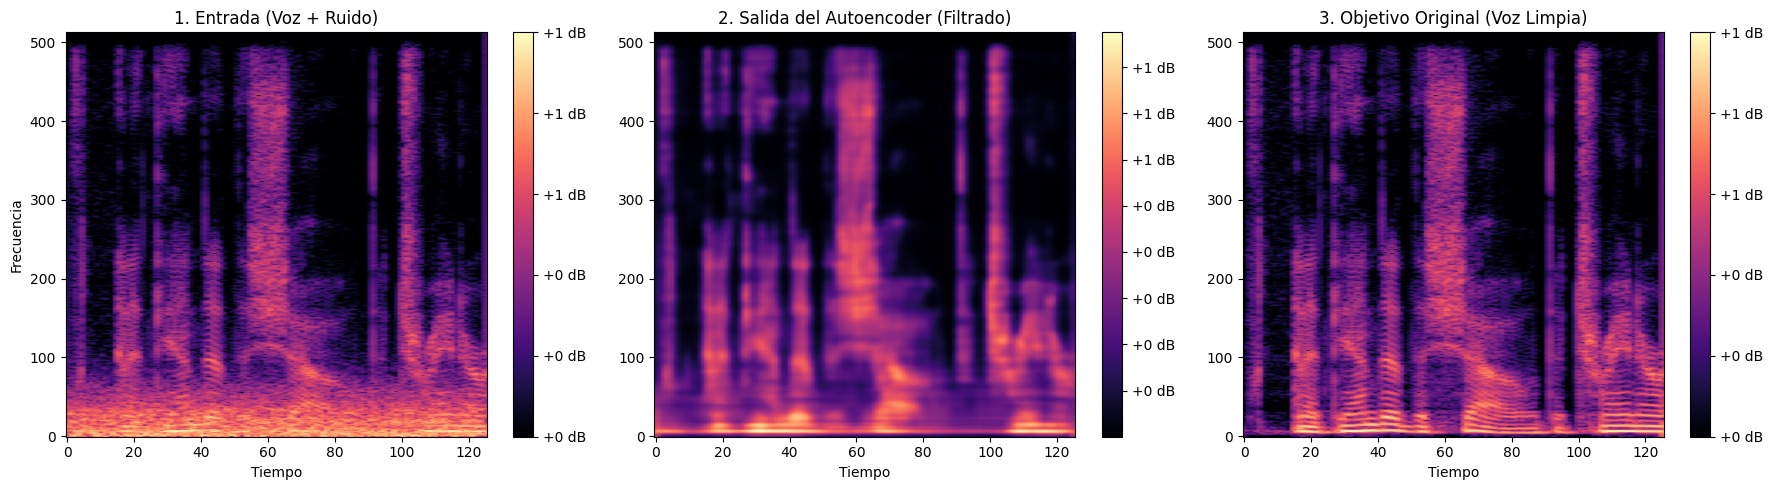

In [17]:
# Indice aleatorio de test
idx = random.randint(0, len(X_test) - 1)

# Extraemos la entrada ruidosa y limpia
sample_corrupto = np.expand_dims(X_test[idx], axis=0)
sample_limpio = Y_test[idx]

# Lo pasamos por el modelo
prediccion = autoencoder.predict(sample_corrupto)

# Quitamos la dimensión del batch y del canal para poder dibujarlos
img_corrupta = np.squeeze(sample_corrupto)
img_prediccion = np.squeeze(prediccion)
img_limpia = np.squeeze(sample_limpio)

plt.figure(figsize=(18, 5))

# Con Ruido
plt.subplot(1, 3, 1)
plt.title("1. Entrada (Voz + Ruido)")
plt.imshow(img_corrupta, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")
plt.colorbar(format='%+2.0f dB')

# Predicción del Autoencoder
plt.subplot(1, 3, 2)
plt.title("2. Salida del Autoencoder (Filtrado)")
plt.imshow(img_prediccion, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')

# Limpia
plt.subplot(1, 3, 3)
plt.title("3. Objetivo Original (Voz Limpia)")
plt.imshow(img_limpia, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

**Conclusión Visual**

Al observar las tres gráficas, podemos confirmar visualmente el éxito del modelo y extraer conclusiones técnicas importantes como:

- **Eliminación de Ruido:** El Autoencoder ha logrado limpiar casi por completo la franja inferior `(ruido de baja frecuencia)` y las interferencias estáticas del fondo, devolviendo el lienzo a un tono oscuro muy similar al objetivo.
- **Efecto de Suavizado:** Notamos que la predicción `(espectrograma del centro)` está más difuminada que la voz real `(espectrograma de la derecha)`. Esto es un efecto secundario que ocurre por dos motivos:
    1. La compresión extrema en el bottleneck hace que se pierdan los detalles de más alta frecuencia.
    2. El uso de la función de pérdida `mse` tiende a promediar las predicciones, generando resultados más suaves y menos nítidos.